# Getting Started: Geometry Override for H2

This notebook shows how to run a calculation with an explicit geometry instead
of relying only on the built-in molecule registry.

Goals:

- inspect the default `H2` geometry from the registry
- define a custom `H2` geometry explicitly
- run VQE on both setups
- compare the returned energies

Unit contract used throughout the package:

- coordinate inputs may be given in `angstrom` or `bohr`
- the chosen `unit` affects geometry only
- reported energies stay in Hartree (`Ha`)

This is the basic workflow for moving from registry-based molecules to custom
user-specified geometries.


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import build_hamiltonian, get_exact_spectrum
from common.molecules import MOLECULES
from vqe.core import run_vqe

## Registry geometry

The package includes a built-in molecule registry. We start by inspecting the
stored entry for `H2`.

In [2]:
MOLECULES["H2"]

{'symbols': ['H', 'H'],
 'coordinates': array([[0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.7414]]),
 'charge': 0,
 'basis': 'STO-3G'}

The registry entry gives the default symbols and coordinates used when we call
high-level workflows like `run_vqe(molecule="H2", ...)` without overriding the
geometry.

In [3]:
registry_symbols = MOLECULES["H2"]["symbols"]
registry_coordinates = np.asarray(MOLECULES["H2"]["coordinates"], dtype=float)
registry_basis = MOLECULES["H2"].get("basis", "sto-3g")
registry_charge = MOLECULES["H2"].get("charge", 0)
registry_unit = MOLECULES["H2"].get("unit", "angstrom")

print("Registry symbols     :", registry_symbols)
print("Registry coordinates :")
print(registry_coordinates)
print("Registry basis       :", registry_basis)
print("Registry charge      :", registry_charge)
print("Registry unit        :", registry_unit)

Registry symbols     : ['H', 'H']
Registry coordinates :
[[0.     0.     0.    ]
 [0.     0.     0.7414]]
Registry basis       : STO-3G
Registry charge      : 0
Registry unit        : angstrom


## Define an explicit geometry

Now we define the same molecule directly. This is the pattern to use when:

- you want a different bond length
- you want to sweep geometries
- your system is not one of the pre-registered molecules

Here we choose a simple custom `H2` geometry.

In [4]:
custom_symbols = ["H", "H"]
custom_coordinates = np.array(
    [
        [0.0, 0.0, 0.0],
        [0.80, 0.0, 0.0],
    ],
    dtype=float,
)

custom_basis = "sto-3g"
custom_charge = 0
custom_unit = "angstrom"

print("Custom symbols     :", custom_symbols)
print("Custom coordinates :")
print(custom_coordinates)

Custom symbols     : ['H', 'H']
Custom coordinates :
[[0.  0.  0. ]
 [0.8 0.  0. ]]


## Visual comparison of bond lengths

In [5]:
registry_distance = float(np.linalg.norm(registry_coordinates[1] - registry_coordinates[0]))
custom_distance = float(np.linalg.norm(custom_coordinates[1] - custom_coordinates[0]))

print(f"Registry H-H distance: {registry_distance:.6f} {registry_unit}")
print(f"Custom   H-H distance: {custom_distance:.6f} {custom_unit}")

Registry H-H distance: 0.741400 angstrom
Custom   H-H distance: 0.800000 angstrom


## Build Hamiltonians directly

Before running VQE, it is useful to confirm that both setups can be passed
through the Hamiltonian builder.

In [6]:
H_reg, qubits_reg, hf_reg, symbols_reg, coords_reg, basis_reg, charge_reg, unit_reg = build_hamiltonian(
    molecule="H2",
    mapping="jordan_wigner",
    return_metadata=True,
)

H_custom, qubits_custom, hf_custom, symbols_custom_out, coords_custom_out, basis_custom_out, charge_custom_out, unit_custom_out = build_hamiltonian(
    molecule=None,
    symbols=custom_symbols,
    coordinates=custom_coordinates,
    basis=custom_basis,
    charge=custom_charge,
    unit=custom_unit,
    mapping="jordan_wigner",
    return_metadata=True,
)

print("Registry qubits:", qubits_reg)
print("Custom   qubits:", qubits_custom)

Registry qubits: 4
Custom   qubits: 4


The physical geometry changed, but the workflow boundary stayed the same:

- build a Hamiltonian
- prepare the Hartree-Fock reference
- run the chosen algorithm

## Exact reference energies

For the registry molecule, we can compare against the exact spectrum using the
built-in helper.

In [7]:
exact_registry_spectrum = np.asarray(get_exact_spectrum("H2"), dtype=float)
exact_registry_spectrum = np.sort(exact_registry_spectrum)
exact_registry_ground_energy = float(exact_registry_spectrum[0])

print("Registry exact spectrum:")
print(exact_registry_spectrum)
print()
print(f"Registry exact ground-state energy: {exact_registry_ground_energy:.10f}")

Registry exact spectrum:
[-1.13727017 -0.53870958 -0.53870958 -0.53247901 -0.53247901 -0.53247901
 -0.44698573 -0.44698573 -0.1699014   0.23780527]

Registry exact ground-state energy: -1.1372701749


For the custom geometry, we can still build the Hamiltonian directly, but here
we focus on comparing the returned VQE energies rather than constructing a full
exact-spectrum helper workflow around the custom geometry.

## Run VQE with the registry geometry

In [8]:
res_registry = run_vqe(
    molecule="H2",
    ansatz_name="UCCSD",
    optimizer_name="Adam",
    steps=50,
    stepsize=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)

Step 01/50: E = -1.116684 Ha
Step 02/50: E = -1.136994 Ha
Step 03/50: E = -1.131007 Ha
Step 04/50: E = -1.122700 Ha
Step 05/50: E = -1.130115 Ha


Step 06/50: E = -1.133031 Ha
Step 07/50: E = -1.134496 Ha
Step 08/50: E = -1.134652 Ha
Step 09/50: E = -1.132102 Ha
Step 10/50: E = -1.130839 Ha
Step 11/50: E = -1.133769 Ha
Step 12/50: E = -1.136856 Ha
Step 13/50: E = -1.136817 Ha
Step 14/50: E = -1.134837 Ha
Step 15/50: E = -1.133732 Ha
Step 16/50: E = -1.134458 Ha
Step 17/50: E = -1.135957 Ha
Step 18/50: E = -1.136742 Ha
Step 19/50: E = -1.136508 Ha
Step 20/50: E = -1.136055 Ha
Step 21/50: E = -1.135899 Ha
Step 22/50: E = -1.135938 Ha
Step 23/50: E = -1.136174 Ha
Step 24/50: E = -1.136688 Ha
Step 25/50: E = -1.137068 Ha
Step 26/50: E = -1.136886 Ha
Step 27/50: E = -1.136406 Ha
Step 28/50: E = -1.136270 Ha
Step 29/50: E = -1.136684 Ha
Step 30/50: E = -1.137181 Ha
Step 31/50: E = -1.137213 Ha
Step 32/50: E = -1.136850 Ha
Step 33/50: E = -1.136654 Ha
Step 34/50: E = -1.136858 Ha
Step 35/50: E = -1.137135 Ha
Step 36/50: E = -1.137184 Ha
Step 37/50: E = -1.137075 Ha
Step 38/50: E = -1.137000 Ha
Step 39/50: E = -1.137018 Ha
Step 40/50: E 

In [9]:
energy_registry = float(res_registry["energy"])
energies_registry = np.asarray(res_registry["energies"], dtype=float)

print(f"Registry VQE final energy: {energy_registry:.10f}")

Registry VQE final energy: -1.1371763799


## Run VQE with the explicit geometry

We now pass the geometry directly into `run_vqe(...)`.

In [10]:
res_custom = run_vqe(
    molecule=None,
    symbols=custom_symbols,
    coordinates=custom_coordinates,
    basis=custom_basis,
    charge=custom_charge,
    unit=custom_unit,
    ansatz_name="UCCSD",
    optimizer_name="Adam",
    steps=50,
    stepsize=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)

Step 01/50: E = -1.110850 Ha
Step 02/50: E = -1.133180 Ha
Step 03/50: E = -1.129613 Ha
Step 04/50: E = -1.114801 Ha
Step 05/50: E = -1.125287 Ha
Step 06/50: E = -1.126504 Ha
Step 07/50: E = -1.128576 Ha
Step 08/50: E = -1.130967 Ha
Step 09/50: E = -1.129750 Ha
Step 10/50: E = -1.127087 Ha
Step 11/50: E = -1.126753 Ha
Step 12/50: E = -1.129685 Ha
Step 13/50: E = -1.133152 Ha
Step 14/50: E = -1.133879 Ha
Step 15/50: E = -1.131597 Ha
Step 16/50: E = -1.129565 Ha
Step 17/50: E = -1.130240 Ha
Step 18/50: E = -1.132450 Ha
Step 19/50: E = -1.133749 Ha
Step 20/50: E = -1.133387 Ha
Step 21/50: E = -1.132477 Ha
Step 22/50: E = -1.132149 Ha
Step 23/50: E = -1.132526 Ha
Step 24/50: E = -1.133065 Ha
Step 25/50: E = -1.133338 Ha
Step 26/50: E = -1.133425 Ha
Step 27/50: E = -1.133523 Ha
Step 28/50: E = -1.133535 Ha
Step 29/50: E = -1.133336 Ha
Step 30/50: E = -1.133190 Ha
Step 31/50: E = -1.133445 Ha
Step 32/50: E = -1.133916 Ha
Step 33/50: E = -1.134074 Ha
Step 34/50: E = -1.133779 Ha
Step 35/50: E 

In [11]:
energy_custom = float(res_custom["energy"])
energies_custom = np.asarray(res_custom["energies"], dtype=float)

print(f"Custom geometry VQE final energy: {energy_custom:.10f}")

Custom geometry VQE final energy: -1.1341069827


## Compare the two runs

Changing the geometry changes the Hamiltonian, so the final energy changes too.

In [12]:
print(f"{'Case':<22} {'Bond length':>14} {'Final energy':>18}")
print("-" * 58)
print(f"{'Registry H2':<22} {registry_distance:>14.6f} {energy_registry:>18.10f}")
print(f"{'Custom geometry H2':<22} {custom_distance:>14.6f} {energy_custom:>18.10f}")

Case                      Bond length       Final energy
----------------------------------------------------------
Registry H2                  0.741400      -1.1371763799
Custom geometry H2           0.800000      -1.1341069827


## Energy trajectories

We can also compare the optimization traces directly.

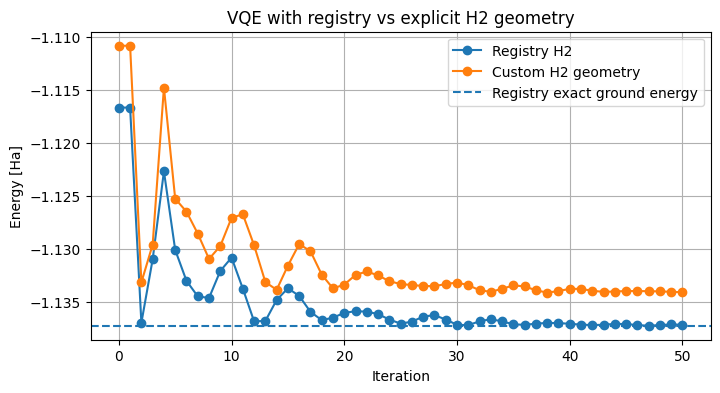

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(energies_registry)), energies_registry, marker="o", label="Registry H2")
plt.plot(np.arange(len(energies_custom)), energies_custom, marker="o", label="Custom H2 geometry")
plt.axhline(exact_registry_ground_energy, linestyle="--", label="Registry exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("VQE with registry vs explicit H2 geometry")
plt.grid(True)
plt.legend()
plt.show()

## What changed and what did not

What changed:

- the nuclear coordinates
- the resulting electronic Hamiltonian
- the final variational energy

What did not change:

- the high-level `run_vqe(...)` workflow
- the ansatz / optimizer interface
- the general plotting and result structure

## Interpretation

The built-in molecule registry is convenient for quick examples, but explicit
geometry overrides are what make the package flexible for real studies.

This same pattern extends naturally to:

- bond scans
- angle scans
- custom molecular systems
- non-registry geometries used in method comparisons

## What this notebook showed

We:

- inspected the default `H2` registry entry
- defined a custom `H2` geometry explicitly
- built both Hamiltonians
- ran VQE on both setups
- compared the returned energies and trajectories

This is the basic geometry-override workflow in the repository.